In [1]:
import numpy as np
import re

from qiskit import transpile
from qiskit_noise_model import *
from qiskit_trotter_circuit import *
import matplotlib.pyplot as plt

from qiskit.circuit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import SparsePauliOp, Operator

# Test

In [13]:
X = SparsePauliOp("X")
Y = SparsePauliOp("Y")
Z = SparsePauliOp("Z")
I = SparsePauliOp("I")
 
# build the evolution gate
operator = 0.5*(X ^ X) + 0.5*(Y ^ Y)
evo = PauliEvolutionGate(operator, time=0.2)

qc = QuantumCircuit(2)
qc.append(evo, range(2))
qc = transpile(qc, basis_gates=["rzz", "u"], optimization_level=3)

qc.draw()

c:\Users\Jielun\Documents\GitHub\one_hot_QTT\.venv\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
c:\Users\Jielun\Documents\GitHub\one_hot_QTT\.venv\Lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


global phase: 3π/2
     ┌────────────┐          ┌───────────────┐          ┌──────────────────┐
q_0: ┤ U(π/2,0,π) ├─■────────┤ U(π/2,0,-π/2) ├─■────────┤ U(-π/2,-π/2,π/2) ├
     ├────────────┤ │ZZ(0.2) ├───────────────┤ │ZZ(0.2) ├──────────────────┤
q_1: ┤ U(π/2,0,π) ├─■────────┤ U(π/2,0,-π/2) ├─■────────┤ U(-π/2,-π/2,π/2) ├
     └────────────┘          └───────────────┘          └──────────────────┘

# Test Trotter noises

## Fidelity

In [ ]:
D = 1
n = 2
dt = 0.01
n_steps_list = range(30)
noise_rate = 0.001

curves = {}
probs = {}
for p in [1E-4]:
    for logq in [2, 3]:
        sim = TrotterNoisySim(D, n, logq, dt, n_steps_list, noise_rate)
        sim.get_fidelity_with_noise()

        q = 2**logq
        nb = n*logq
        curves[f"binary (nb = {nb}, N = {2**nb})"] = sim.binary_fidelities
        curves[f"one-hot (n={n}, q={2**logq}, N = {q**n})"] = sim.one_hot_fidelities
        curves[f"one-hot projected (n={n}, q={2**logq})"] = sim.one_hot_projected_fidelities
        probs[f"one-hot (n={n}, q={2**logq})"] = sim.fidelity_sucess_probs

====Running: D=1, n=2, q=4, dt=0.01====
Running: n_steps=0
Running: n_steps=1
Running: n_steps=2
Running: n_steps=3
Running: n_steps=4
Running: n_steps=5
Running: n_steps=6
Running: n_steps=7
Running: n_steps=8
Running: n_steps=9
Running: n_steps=10
Running: n_steps=11
Running: n_steps=12
Running: n_steps=13
Running: n_steps=14
Running: n_steps=15
Running: n_steps=16
Running: n_steps=17
Running: n_steps=18
Running: n_steps=19
Running: n_steps=20
Running: n_steps=21
Running: n_steps=22
Running: n_steps=23
Running: n_steps=24
Running: n_steps=25
Running: n_steps=26
Running: n_steps=27
Running: n_steps=28
Running: n_steps=29
====Running: D=1, n=2, q=8, dt=0.01====
Running: n_steps=0


CircuitTooWideForTarget: 'Number of qubits (16) in circuit-3406 is greater than maximum (15) in the coupling_map'

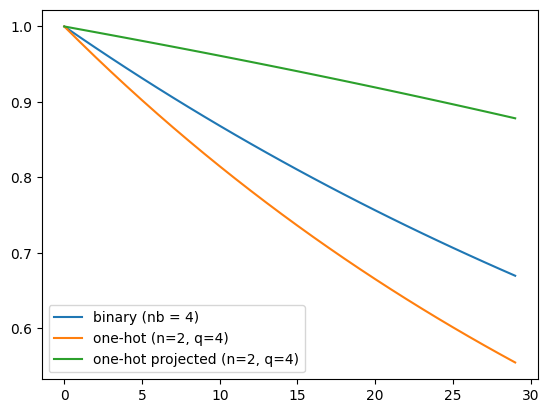

In [7]:
for key, val in curves.items():
    plt.plot(val, label=key)
plt.legend()

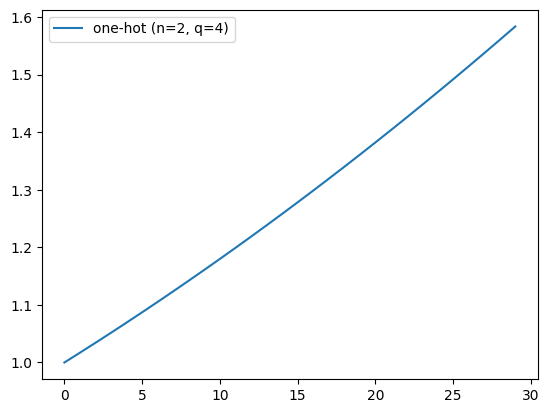

In [10]:
for key, val in probs.items():
    plt.plot(1/np.array(val), label=key)
plt.legend()

## TVD

In [ ]:
D = 1
n = 2
dt = 0.01
shots = 5000
n_steps_list = range(30)

curves = {}
probs = {}
for p in [1E-4]:
    for logq in [2]:
        sim = TrotterNoisySim(D, n, logq, dt, n_steps_list)
        noise_model = depolarizing_noise_model(p)
        sim.get_tvd_with_noise(noise_model)

        curves[f"binary (nb = {n*logq}), p = {p}"] = sim.binary_tv_curve
        curves[f"one-hot (n={n}, q={2**logq}), p = {p}"] = sim.one_hot_tv_curve
        curves[f"one-hot projected (n={n}, q={2**logq}), p = {p}"] = sim.one_hot_projected_tv_curce

        probs[f"one-hot (n={n}, q={2**logq}), p = {p}"] = sim.sucess_probs

AttributeError: 'TrotterNoisySim' object has no attribute 'run_with_noise'

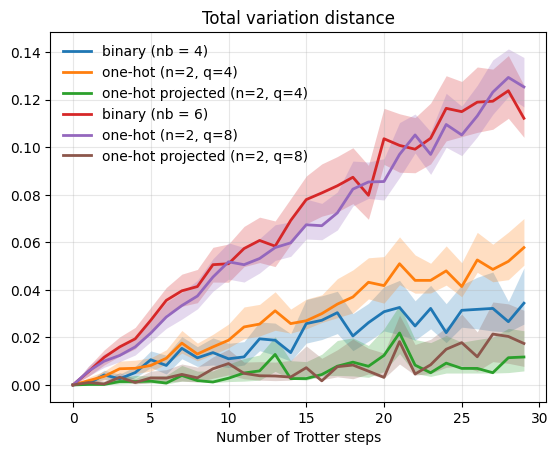

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Total variation distance'}, xlabel='Number of Trotter steps'>)

In [32]:
def plot_tv_curve(curves, 
                  xlabel: str = "Number of Trotter steps",
                  ylabel: str | None = None,
                  title: str | None = None,
                  alpha_band: float = 0.25,
                  lw: float = 2.0,):
    
    fig, ax = plt.subplots()

    for label, data in curves.items():
        label = re.sub(r",\s*p\s*=.*$", "", label)
        line, = ax.plot(data["t"], data["y"], lw=lw, label=label)
        color = line.get_color()
        if "y_lo" in data:
            ax.fill_between(
                data["t"], data["y_lo"], data["y_hi"],
                color=color, alpha=alpha_band, linewidth=0
            )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    #ax.set_ylim(0, 1)
    if title:
        ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(frameon=False)
    plt.show()

    return fig, ax

plot_tv_curve(curves, title="Total variation distance")

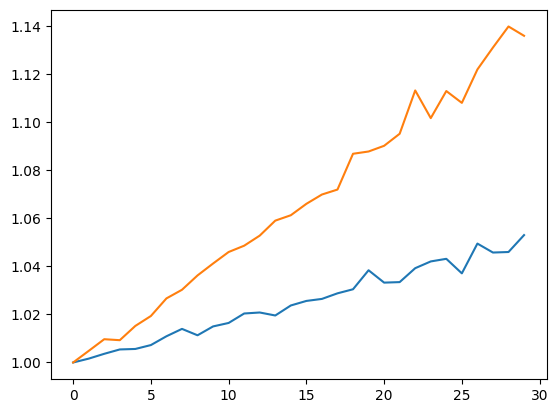

In [24]:
plt.plot(1/np.array(probs["one-hot (n=2, q=4), p = 0.0001"]))
plt.plot(1/np.array(probs["one-hot (n=2, q=8), p = 0.0001"]))

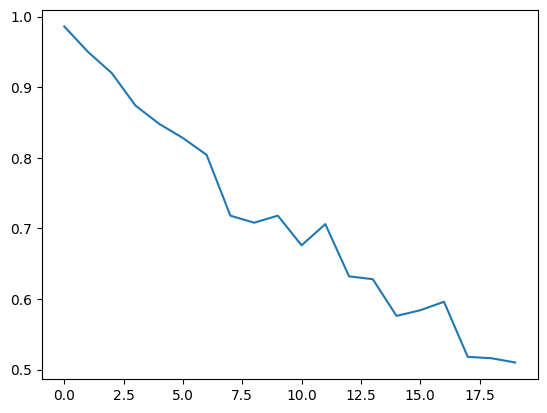

In [18]:
plt.plot(success_probs)

In [8]:
#ideal_binary, ideal_one_hot